In [1]:
# CELL 1
# Ops AI - Entity Risk Model

#Notebook này dùng để:
#- huấn luyện mô hình Ops AI trên lõi mới `api/process_ai`
#- đọc metrics và artifact đã sinh ra
#- hiển thị confusion matrix và feature importance
#- thử dự đoán cho một route mẫu

#Bài toán hiện tại:
#- dự đoán route có severe operational disruption trong 3 tháng tới hay không

#Notebook này chỉ đóng vai trò:
#- điều phối
#- phân tích
#- trình bày kết quả

#Logic lõi nằm trong:
#- `api.process_ai.core`
#- `api.process_ai.entity`

In [2]:
# CELL 2
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from api.process_ai.entity.builders.ops import (
    default_ops_task_spec,
    build_ops_training_frame,
)
from api.process_ai.entity.trainers import train_ops_entity_model
from api.process_ai.entity.inference import predict_ops_risk, print_ops_prediction_report

sns.set_theme(style="whitegrid")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"

In [3]:
# CELL 3
spec = default_ops_task_spec()
spec

TaskSpec(task_key='ops_ai', task_kind='entity', artifact_dir=WindowsPath('D:/logistics_AI/model/entity_models/ops'), label_column='target_next_3m_severe_ops_disruption', model_candidates=['logreg', 'rf', 'hgb'], threshold_policy='fixed_0_5', validation_months=3, test_months=6, random_state=42, legacy_model_path=None, metadata={'entity_name': 'ops', 'builder_name': 'ops'})

In [4]:
# CELL 4
result = train_ops_entity_model(spec)

=== RUN TRAINING PIPELINE: ops_ai (entity) ===
=== FIT MODEL ===
=== MODEL BENCHMARK ON VALIDATION ===

--- TRAIN LOGREG ---
logreg | PR-AUC=0.5096099258324892 | ROC-AUC=0.5223090162849199 | Recall=0.5180722891566265 | Pred+Rate=0.5

--- TRAIN RF ---
rf | PR-AUC=0.48162632049392096 | ROC-AUC=0.5298556864821925 | Recall=0.40963855421686746 | Pred+Rate=0.39655172413793105

--- TRAIN HGB ---
hgb | PR-AUC=0.5742951696214458 | ROC-AUC=0.5923474116245201 | Recall=0.39759036144578314 | Pred+Rate=0.3505747126436782

=== BEST MODEL ON VALIDATION ===
Best model: hgb
Best validation PR-AUC: 0.5742951696214458

=== THRESHOLD SWEEP ON VALIDATION ===
 threshold  accuracy  precision   recall       f1  predicted_positive_rate  tp  fp  tn  fn
      0.10  0.488506   0.482353 0.987952 0.648221                 0.977011  82  88   3   1
      0.15  0.500000   0.487179 0.915663 0.635983                 0.896552  76  80  11   7
      0.20  0.534483   0.506849 0.891566 0.646288                 0.839080  74  72

In [5]:
# CELL 5
metrics = result.metrics

{
    "best_model_name": metrics.get("best_model_name"),
    "threshold": metrics.get("threshold"),
    "accuracy": metrics.get("accuracy"),
    "precision": metrics.get("precision"),
    "recall": metrics.get("recall"),
    "f1": metrics.get("f1"),
    "roc_auc": metrics.get("roc_auc"),
    "pr_auc": metrics.get("pr_auc"),
    "train_positive_rate": metrics.get("train_positive_rate"),
    "test_positive_rate": metrics.get("test_positive_rate"),
    "predicted_positive_rate": metrics.get("predicted_positive_rate"),
}

{'best_model_name': 'hgb',
 'threshold': 0.5,
 'accuracy': 0.4885057471264368,
 'precision': 0.4367816091954023,
 'recall': 0.48717948717948717,
 'f1': 0.46060606060606063,
 'roc_auc': 0.5219350961538463,
 'pr_auc': 0.4748325549735307,
 'train_positive_rate': 0.46998722860791825,
 'test_positive_rate': 0.4482758620689655,
 'predicted_positive_rate': 0.5}

In [6]:
# CELL 6
metrics_path = Path(result.artifact_paths["metrics_path"])
with open(metrics_path, "r", encoding="utf-8") as f:
    metrics_json = json.load(f)

metrics_json

{'threshold': 0.5,
 'accuracy': 0.4885057471264368,
 'precision': 0.4367816091954023,
 'recall': 0.48717948717948717,
 'f1': 0.46060606060606063,
 'roc_auc': 0.5219350961538463,
 'pr_auc': 0.4748325549735307,
 'positive_rate_test': 0.4482758620689655,
 'predicted_positive_rate': 0.5,
 'classification_report': {'0': {'precision': 0.5402298850574713,
   'recall': 0.4895833333333333,
   'f1-score': 0.5136612021857924,
   'support': 192.0},
  '1': {'precision': 0.4367816091954023,
   'recall': 0.48717948717948717,
   'f1-score': 0.46060606060606063,
   'support': 156.0},
  'accuracy': 0.4885057471264368,
  'macro avg': {'precision': 0.4885057471264368,
   'recall': 0.48838141025641024,
   'f1-score': 0.48713363139592647,
   'support': 348.0},
  'weighted avg': {'precision': 0.4938565200158541,
   'recall': 0.4885057471264368,
   'f1-score': 0.48987786285694707,
   'support': 348.0}},
 'confusion_matrix': [[94, 98], [80, 76]],
 'feature_importance': {'months_since_last_severe_ops_month': 0.

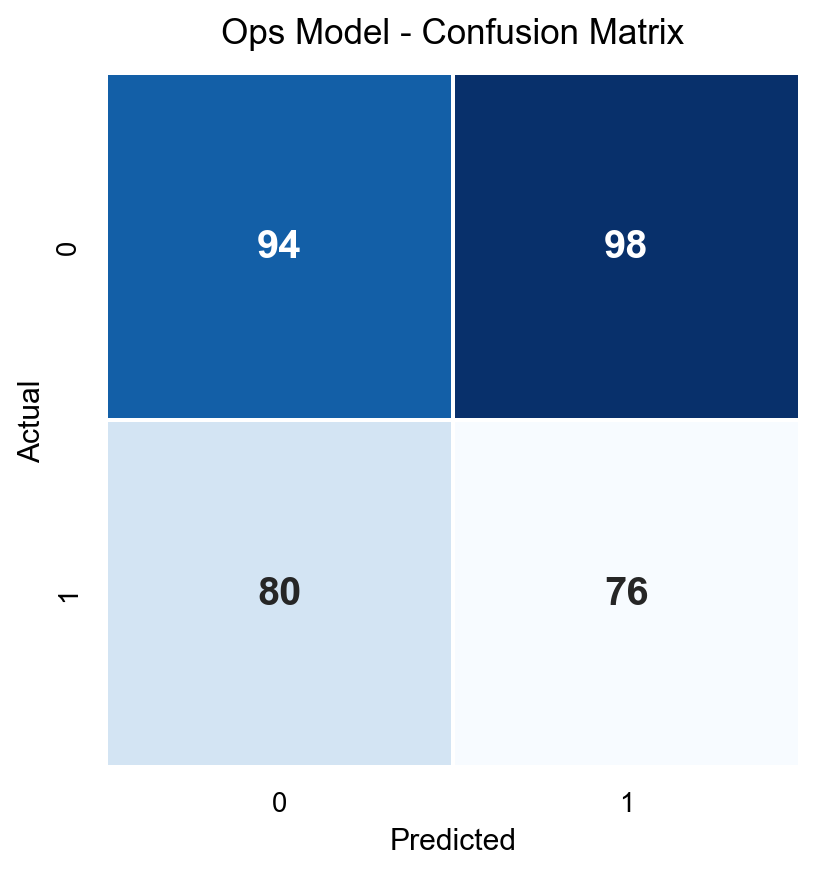

In [7]:
# CELL 7
conf_matrix_path = Path(result.artifact_paths["confusion_matrix_png"])
display(Image(filename=str(conf_matrix_path)))

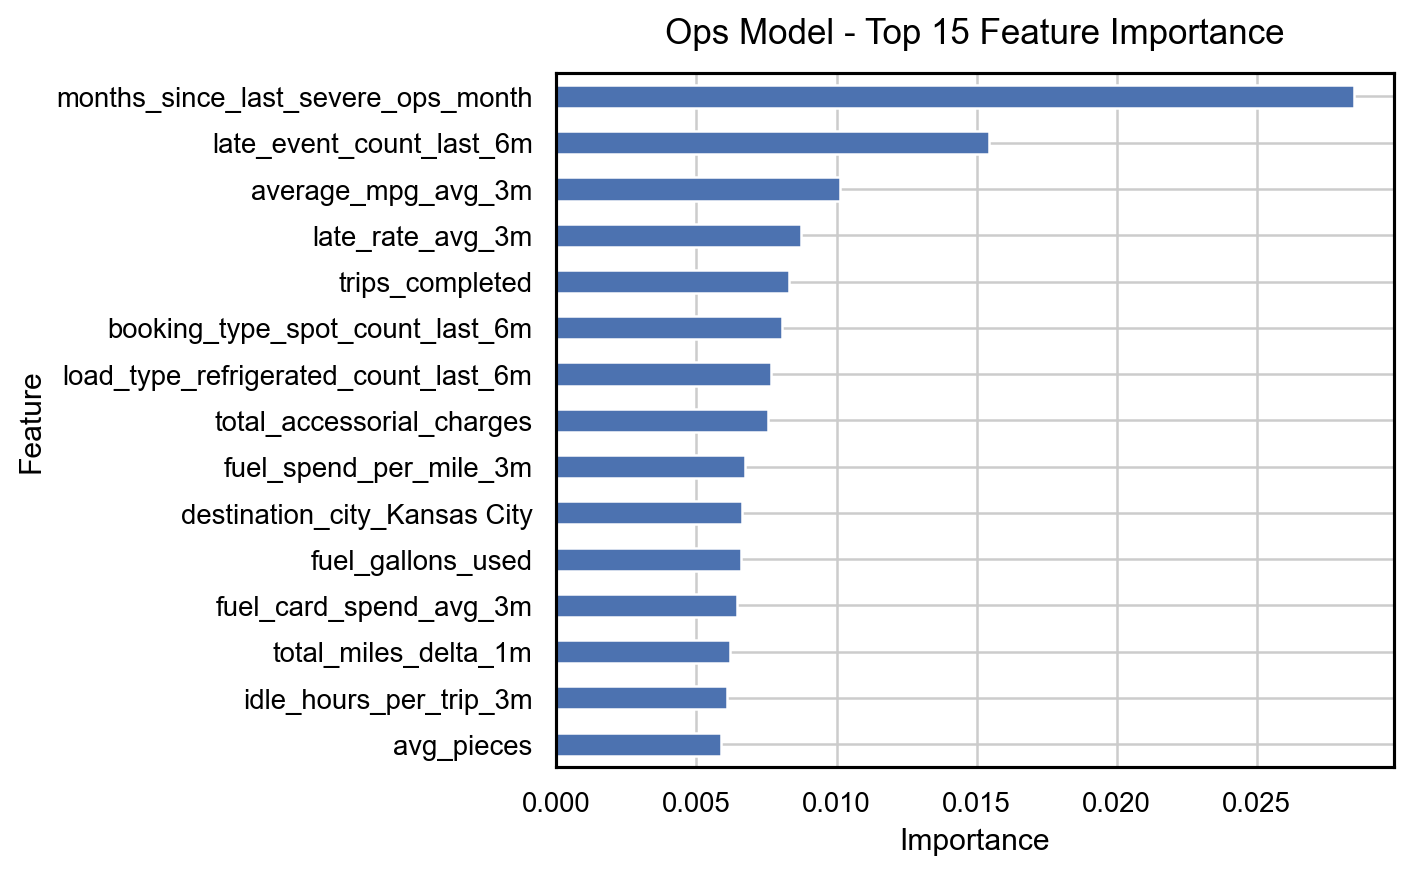

In [8]:
# CELL 8
feature_importance_path = Path(result.artifact_paths["feature_importance_png"])
display(Image(filename=str(feature_importance_path)))

In [9]:
# CELL 9
ops_df = build_ops_training_frame()
print(f"Shape: {ops_df.shape}")
ops_df.head()

Shape: (1914, 206)


,route_id,month,trips_completed,total_miles,total_duration_hours,fuel_gallons_used,average_mpg,total_idle_hours,total_revenue,total_fuel_surcharge,...,destination_city_Philadelphia,destination_city_Portland,destination_city_Seattle,severe_ops_in_1m_count,severe_ops_in_2m_count,severe_ops_in_3m_count,target_next_3m_severe_ops_count,target_next_3m_severe_ops_disruption,severe_late_rate_threshold,severe_detention_avg_threshold
0,RTE00001,2022-01-01,40,27823,490.4,4274.9,6.567000,249.7,45259.54,5145.20,...,0,0,0,0,0,0,0,0,0.510942,101.27336
1,RTE00001,2022-02-01,45,31270,548.1,4836.0,6.518000,298.1,51169.10,5788.35,...,0,0,0,0,0,0,0,0,0.510942,101.27336
2,RTE00001,2022-03-01,34,23706,408.3,3754.3,6.380000,214.3,39131.65,4373.42,...,0,0,0,0,0,0,0,0,0.510942,101.27336
3,RTE00001,2022-04-01,36,25136,444.7,3946.9,6.422500,252.7,40677.75,4630.68,...,0,0,0,0,0,0,0,0,0.510942,101.27336
4,RTE00001,2022-05-01,44,30489,532.8,4716.0,6.520909,356.9,50640.11,5659.72,...,0,0,0,0,0,1,1,1,0.510942,101.27336


In [10]:
# CELL 10
sample_input = ops_df.iloc[[0]].to_dict(orient="records")[0]

pred_result, pred_meta = predict_ops_risk(sample_input, return_metadata=True)
print_ops_prediction_report(pred_result, pred_meta)

=== OPS RISK PREDICTION REPORT ===
Threshold               : 0.5
Expected feature count  : 141
Used feature count      : 141
Missing feature count   : 0
Extra input count       : 65
Target definition       : Predict whether route has severe operational disruption in next 3 months
Extra input columns     : ['route_id', 'month', 'trips_completed_lag1', 'total_miles_lag1', 'total_duration_hours_lag1', 'fuel_gallons_used_avg_3m', 'fuel_gallons_used_lag1', 'fuel_gallons_used_delta_1m', 'average_mpg_lag1', 'total_idle_hours_lag1', 'total_revenue_lag1', 'total_fuel_surcharge_avg_3m', 'total_fuel_surcharge_lag1', 'total_fuel_surcharge_delta_1m', 'total_accessorial_charges_avg_3m', 'total_accessorial_charges_lag1', 'total_accessorial_charges_delta_1m', 'avg_weight_lbs_avg_3m', 'avg_weight_lbs_lag1', 'avg_weight_lbs_delta_1m', 'avg_pieces_avg_3m', 'avg_pieces_lag1', 'avg_pieces_delta_1m', 'event_count_avg_3m', 'event_count_lag1', 'event_count_delta_1m', 'pickup_count_avg_3m', 'pickup_count_lag1'

In [11]:
# CELL 11
ops_plot_df = build_ops_training_frame().copy()

target_col = "target_next_3m_severe_ops_disruption"
ops_plot_df["ops_rating"] = ops_plot_df[target_col].astype(int)

# detention theo giờ cho dễ nhìn
if "detention_avg" in ops_plot_df.columns:
    ops_plot_df["detention_hours"] = ops_plot_df["detention_avg"] / 60.0
else:
    ops_plot_df["detention_hours"] = 0.0

# delay_hours từ detention_sum / event_count như một proxy
if "detention_sum" in ops_plot_df.columns and "event_count" in ops_plot_df.columns:
    ops_plot_df["delay_hours"] = (
        ops_plot_df["detention_sum"] / (ops_plot_df["event_count"] + 1e-6)
    ) / 60.0
else:
    ops_plot_df["delay_hours"] = 0.0

ops_plot_df[[
    "route_id",
    "month",
    "ops_rating",
    "detention_hours",
    "total_miles",
    "average_mpg",
    "delay_hours"
]].head()

,route_id,month,ops_rating,detention_hours,total_miles,average_mpg,delay_hours
0,RTE00001,2022-01-01,0,1.271097,27823,6.567000,1.271097
1,RTE00001,2022-02-01,0,1.660926,31270,6.518000,1.660926
2,RTE00001,2022-03-01,0,1.615217,23706,6.380000,1.615217
3,RTE00001,2022-04-01,0,1.532160,25136,6.422500,1.532160
4,RTE00001,2022-05-01,1,1.394697,30489,6.520909,1.394697


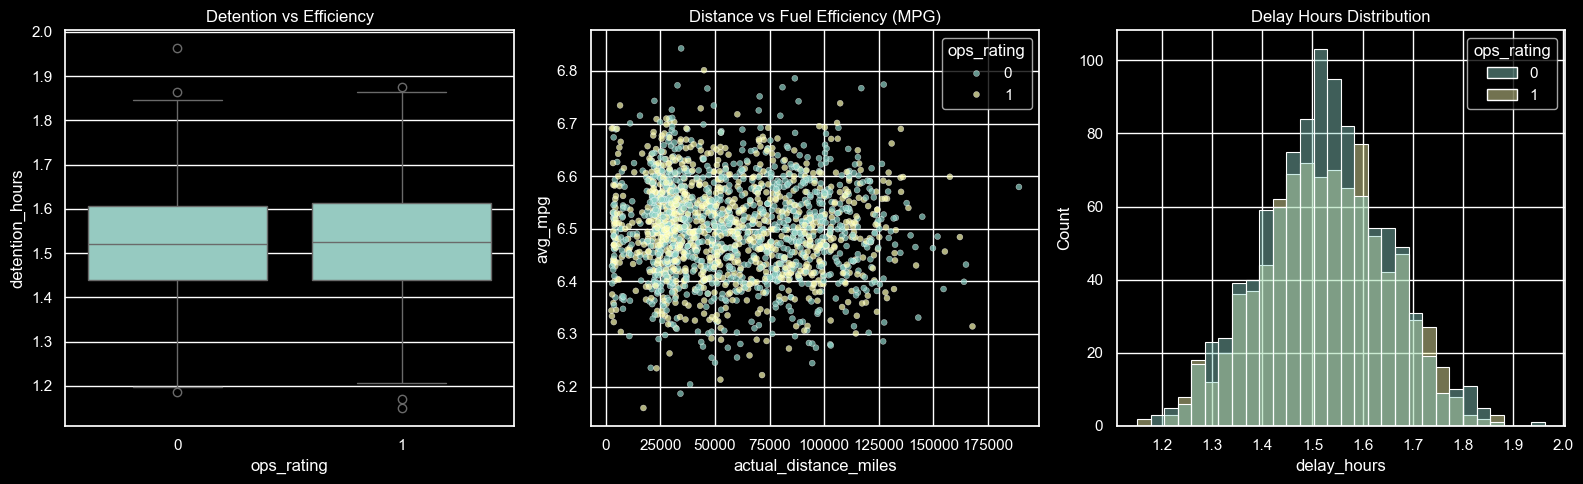

Đã lưu hình tại: D:\logistics_AI\model\entity_models\ops\ops_eda_panel.png


In [12]:
# CELL 12
save_path = Path(spec.artifact_dir) / "ops_eda_panel.png"

# style tối giống hình mẫu
sns.set_theme(style="darkgrid")
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Thời gian chờ vs hiệu quả
sns.boxplot(
    data=ops_plot_df,
    x="ops_rating",
    y="detention_hours",
    ax=axes[0],
)
axes[0].set_title("Detention vs Efficiency")
axes[0].set_xlabel("ops_rating")
axes[0].set_ylabel("detention_hours")

# 2) Khoảng cách vs hiệu suất nhiên liệu
sns.scatterplot(
    data=ops_plot_df,
    x="total_miles",
    y="average_mpg",
    hue="ops_rating",
    alpha=0.7,
    s=18,
    ax=axes[1],
)
axes[1].set_title("Distance vs Fuel Efficiency (MPG)")
axes[1].set_xlabel("actual_distance_miles")
axes[1].set_ylabel("avg_mpg")

# 3) Phân bố thời gian trễ
sns.histplot(
    data=ops_plot_df,
    x="delay_hours",
    hue="ops_rating",
    bins=30,
    kde=False,
    stat="count",
    alpha=0.45,
    ax=axes[2],
)
axes[2].set_title("Delay Hours Distribution")
axes[2].set_xlabel("delay_hours")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Đã lưu hình tại: {save_path}")

In [13]:
# CELL 13
artifact_summary = pd.DataFrame([
    {
        "artifact_name": "Ops EDA Panel",
        "file_path": str(Path(spec.artifact_dir) / "ops_eda_panel.png"),
        "use_for_report": "Hình trực quan hóa dữ liệu Ops AI",
    },
    {
        "artifact_name": "Confusion matrix",
        "file_path": str(Path(spec.artifact_dir) / "confusion_matrix.png"),
        "use_for_report": "Hình đánh giá dự đoán của Ops AI",
    },
    {
        "artifact_name": "Feature importance",
        "file_path": str(Path(spec.artifact_dir) / "feature_importance.png"),
        "use_for_report": "Hình giải thích biến quan trọng của Ops AI",
    },
    {
        "artifact_name": "Metrics JSON",
        "file_path": str(Path(spec.artifact_dir) / "metrics.json"),
        "use_for_report": "Nguồn số liệu metric chính",
    },
])

display(artifact_summary)

,artifact_name,file_path,use_for_report
0,Ops EDA Panel,D:\logistics_AI\model\entity_models\ops\ops_ed...,Hình trực quan hóa dữ liệu Ops AI
1,Confusion matrix,D:\logistics_AI\model\entity_models\ops\confus...,Hình đánh giá dự đoán của Ops AI
2,Feature importance,D:\logistics_AI\model\entity_models\ops\featur...,Hình giải thích biến quan trọng của Ops AI
3,Metrics JSON,D:\logistics_AI\model\entity_models\ops\metric...,Nguồn số liệu metric chính
